# Phases 3-6 validation: effective potential, shell filling, SCF loop, total energy

Checks, in order:
1. `potentials.hartree_potential` reproduces the exact hydrogen 1s self-Coulomb energy (5/16 Ha).
2. `shells.ground_state_configuration` matches known reference configurations, including Madelung exceptions.
3. `scf.run_scf` converges for closed-shell atoms (He, Ne, Ar) and Madelung-exception atoms (Cr, Cu), landing within ~0.2-3.5% of literature non-relativistic HF energies (expected gap: this is Xa local exchange, not exact HF).
4. SCF convergence curves and the radial density's shell-peak structure, visually.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

import potentials as pot
import shells
import scf
import hydrogenic as hy

## 1. Hartree potential: exact hydrogen 1s self-Coulomb energy

In [2]:
r = np.linspace(1e-6, 40, 200000)
R10 = hy.radial_wavefunction(1, 0, r, Z=1)
rho_1s = R10**2 / (4 * np.pi)

V_H = pot.hartree_potential(r, rho_1s)
E_H = 0.5 * trapezoid(V_H * rho_1s * 4 * np.pi * r**2, r)
print(f'E_H (numeric)      = {E_H:.8f}')
print(f'E_H (exact, 5/16)  = {5/16:.8f}')
print(f'V_H(r)*r at r=40 (should -> N=1): {V_H[-1]*r[-1]:.8f}')

E_H (numeric)      = 0.31250000
E_H (exact, 5/16)  = 0.31250000
V_H(r)*r at r=40 (should -> N=1): 1.00000000


## 2. Shell filling: known configurations, including Madelung exceptions

In [3]:
for Z, name in [(26, 'Fe'), (24, 'Cr'), (29, 'Cu'), (46, 'Pd'), (57, 'La'), (64, 'Gd'), (92, 'U')]:
    cfg = shells.ground_state_configuration(Z)
    print(f'{name:3s} (Z={Z:3d}, N={sum(cfg.values()):3d}): {shells.format_configuration(cfg)}')

Fe  (Z= 26, N= 26): 1s2 2s2 2p6 3s2 3p6 3d6 4s2
Cr  (Z= 24, N= 24): 1s2 2s2 2p6 3s2 3p6 3d5 4s1
Cu  (Z= 29, N= 29): 1s2 2s2 2p6 3s2 3p6 3d10 4s1
Pd  (Z= 46, N= 46): 1s2 2s2 2p6 3s2 3p6 3d10 4s2 4p6 4d10
La  (Z= 57, N= 57): 1s2 2s2 2p6 3s2 3p6 3d10 4s2 4p6 4d10 5s2 5p6 5d1 6s2
Gd  (Z= 64, N= 64): 1s2 2s2 2p6 3s2 3p6 3d10 4s2 4p6 4d10 4f7 5s2 5p6 5d1 6s2
U   (Z= 92, N= 92): 1s2 2s2 2p6 3s2 3p6 3d10 4s2 4p6 4d10 4f14 5s2 5p6 5d10 5f3 6s2 6p6 6d1 7s2


## 3. Full SCF runs

He/Ne/Ar (closed shell) and Cr/Cu (Madelung exceptions, `mix_beta` lowered for the harder open-shell case). Literature non-relativistic HF energies for comparison: He -2.86168 Ha, Ne -128.547 Ha, Ar -526.818 Ha (no simple literature Xa reference for Cr/Cu at this alpha).

In [4]:
results = {}
for Z, name, kwargs in [
    (2, 'He', {}),
    (10, 'Ne', {}),
    (18, 'Ar', {}),
    (24, 'Cr', {'mix_beta': 0.2}),
    (29, 'Cu', {'mix_beta': 0.2}),
]:
    res = scf.run_scf(Z, max_iter=200, **kwargs)
    results[name] = res
    Q = trapezoid(4 * np.pi * res['r']**2 * res['rho'], res['r'])
    print(f'{name:3s} (Z={Z:3d}): E_total={res["E_total"]:12.5f} Ha  iters={res["iterations"]:4d}  N_check={Q:.6f}  config={shells.format_configuration(res["config"])}')

He  (Z=  2): E_total=    -2.76637 Ha  iters=  29  N_check=2.000000  config=1s2


Ne  (Z= 10): E_total=  -128.03490 Ha  iters=  44  N_check=10.000000  config=1s2 2s2 2p6


Ar  (Z= 18): E_total=  -525.89503 Ha  iters=  45  N_check=18.000000  config=1s2 2s2 2p6 3s2 3p6


Cr  (Z= 24): E_total= -1042.21990 Ha  iters=  73  N_check=24.000000  config=1s2 2s2 2p6 3s2 3p6 3d5 4s1


Cu  (Z= 29): E_total= -1638.28291 Ha  iters=  74  N_check=29.000000  config=1s2 2s2 2p6 3s2 3p6 3d10 4s1


## 4. Convergence curves and radial density shell structure

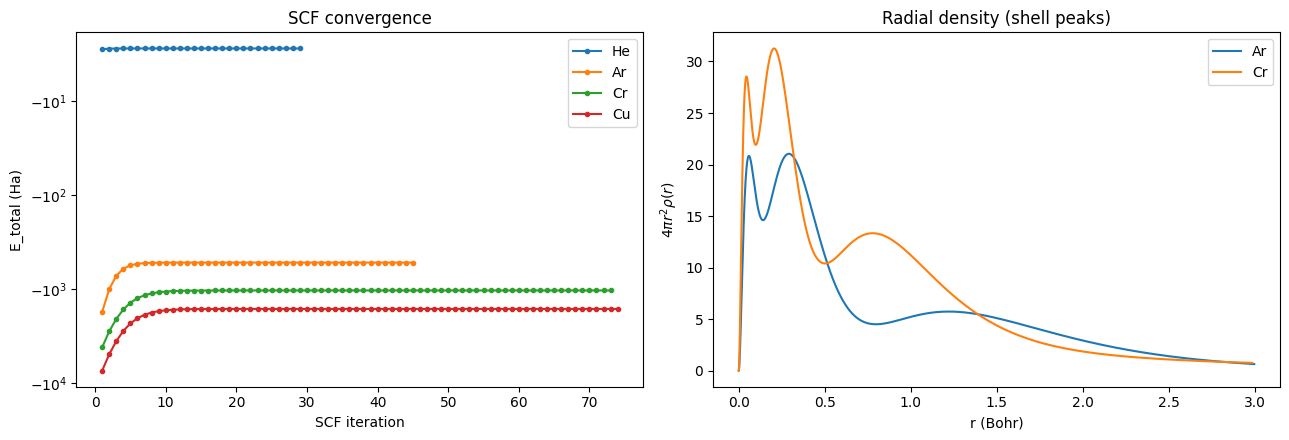

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

for name in ['He', 'Ar', 'Cr', 'Cu']:
    h = results[name]['history']
    axs[0].plot(range(1, len(h) + 1), h, marker='.', label=name)
axs[0].set_xlabel('SCF iteration')
axs[0].set_ylabel('E_total (Ha)')
axs[0].set_yscale('symlog')
axs[0].set_title('SCF convergence')
axs[0].legend()

for name, rmax in [('Ar', 3.0), ('Cr', 3.0)]:
    res = results[name]
    r = res['r']
    mask = r < rmax
    axs[1].plot(r[mask], 4 * np.pi * r[mask]**2 * res['rho'][mask], label=name)
axs[1].set_xlabel('r (Bohr)')
axs[1].set_ylabel(r'$4\pi r^2 \rho(r)$')
axs[1].set_title('Radial density (shell peaks)')
axs[1].legend()

plt.tight_layout()
fig.savefig('media/phase3_6_scf_validation.png', dpi=110)
plt.show()

## 5. Genuine Kohn-Sham LDA (`method="lda"`): adding correlation to the exact-LDA exchange

Everything above uses Slater/X-alpha local exchange only, with a tunable
`alpha` and no correlation term at all -- not actually Hartree-Fock (no
exact non-local exchange) and not actually Kohn-Sham DFT either (no
correlation functional). `potentials.pz81_correlation` (Perdew-Zunger 1981,
fit to Ceperley-Alder QMC data) adds the missing piece: paired with
`ALPHA_LDA` exchange (fixed at the theoretical value, not tuned), this is
genuine, parameter-free Kohn-Sham LDA. `scf.run_scf(Z, method="lda")` runs
it through the same SCF loop, unchanged.

In [6]:
# Correlation functional sanity checks: negative everywhere, continuous across
# the fit's rs=1 branch boundary to its own fit precision (the two branches were
# independently curve-fit to QMC data and only approximately match there by
# construction -- ~3e-5 Ha, a documented artifact of the published parametrization,
# not a bug to chase to exact zero).
rs_test = np.array([0.5, 0.9, 0.99, 1.0, 1.01, 1.1, 2.0, 5.0, 20.0])
rho_test = 3 / (4 * np.pi * rs_test**3)
eps_c_test, V_c_test = pot.pz81_correlation(rho_test)
for rs, e, v in zip(rs_test, eps_c_test, V_c_test):
    print(f'  rs={rs:6.2f}  eps_c={e: .6f} Ha  V_c={v: .6f} Ha')

assert np.all(eps_c_test < 0), 'correlation energy density should be negative everywhere'
assert np.all(V_c_test < 0), 'correlation potential should be negative everywhere'
e_lo, _ = pot.pz81_correlation(3 / (4 * np.pi * np.array([0.999999])**3))
e_hi, _ = pot.pz81_correlation(3 / (4 * np.pi * np.array([1.000001])**3))
assert abs(e_lo[0] - e_hi[0]) < 1e-4, 'eps_c discontinuity at rs=1 larger than the known PZ81 fit artifact'
print('PASS: eps_c, V_c < 0 everywhere tested, continuous across rs=1 to fit-level precision.')

  rs=  0.50  eps_c=-0.076050 Ha  V_c=-0.084586 Ha
  rs=  0.90  eps_c=-0.061906 Ha  V_c=-0.069330 Ha
  rs=  0.99  eps_c=-0.059816 Ha  V_c=-0.067008 Ha
  rs=  1.00  eps_c=-0.059632 Ha  V_c=-0.066794 Ha
  rs=  1.01  eps_c=-0.059418 Ha  V_c=-0.066579 Ha
  rs=  1.10  eps_c=-0.057587 Ha  V_c=-0.064726 Ha
  rs=  2.00  eps_c=-0.045091 Ha  V_c=-0.051813 Ha
  rs=  5.00  eps_c=-0.028339 Ha  V_c=-0.033690 Ha
  rs= 20.00  eps_c=-0.011497 Ha  V_c=-0.014291 Ha
PASS: eps_c, V_c < 0 everywhere tested, continuous across rs=1 to fit-level precision.


### Self-interaction error: the hydrogen atom

Exact Hartree-Fock is *exact* for a single electron -- HF exchange exactly
cancels the spurious self-Coulomb (self-Hartree) interaction, reproducing
the analytic `E = -0.5` Ha exactly (already confirmed in `Radial SCF
Validation.ipynb`'s zeroed-potential check). LDA has no such exact
cancellation: its local exchange only approximately cancels self-Hartree,
and PZ81 correlation adds a further small spurious self-interaction on top.
This is one of DFT's best-known, most-cited limitations (self-interaction
error, SIE) -- and the one-electron hydrogen atom is its cleanest possible
demonstration, with no genuine many-electron physics to confound it.

In [7]:
res_h_lda = scf.run_scf(1, method='lda')
res_h_xexact = scf.run_scf(1, method='xalpha', alpha=pot.ALPHA_LDA)  # exact-LDA exchange, no correlation
print(f'H, exact:                              E = -0.50000 Ha')
print(f'H, exact-LDA exchange only (no corr.): E = {res_h_xexact["E_total"]:.5f} Ha  (SIE = {res_h_xexact["E_total"]-(-0.5):+.5f} Ha)')
print(f'H, LDA (exchange + PZ81 correlation):  E = {res_h_lda["E_total"]:.5f} Ha  (SIE = {res_h_lda["E_total"]-(-0.5):+.5f} Ha)')

assert res_h_lda['E_total'] > -0.5, 'LDA should underbind hydrogen relative to the exact -0.5 Ha (positive SIE)'
print('PASS: LDA shows a genuine, nonzero self-interaction error for the one-electron case, as expected.')

H, exact:                              E = -0.50000 Ha
H, exact-LDA exchange only (no corr.): E = -0.40652 Ha  (SIE = +0.09348 Ha)
H, LDA (exchange + PZ81 correlation):  E = -0.44588 Ha  (SIE = +0.05412 Ha)
PASS: LDA shows a genuine, nonzero self-interaction error for the one-electron case, as expected.


### LDA vs. X-alpha vs. literature Hartree-Fock, closed-shell atoms

Same He/Ne/Ar cases as section 3 above, now also run with `method="lda"`.
LDA has no tunable parameter (unlike Xalpha's `alpha`), so there is exactly
one number to report per atom, not a family of them.

In [8]:
lit_hf = {2: -2.86168, 10: -128.547, 18: -526.818}
lda_results = {}
for Z, name in [(2, 'He'), (10, 'Ne'), (18, 'Ar')]:
    res = scf.run_scf(Z, method='lda', max_iter=200)
    lda_results[name] = res
    Q = trapezoid(4 * np.pi * res['r']**2 * res['rho'], res['r'])
    print(f'{name:3s}: LDA={res["E_total"]:11.5f} Ha   Xalpha(Schwarz)={results[name]["E_total"]:11.5f} Ha   '
          f'lit. HF={lit_hf[Z]:11.5f} Ha   N_check={Q:.6f}')

He : LDA=   -2.83418 Ha   Xalpha(Schwarz)=   -2.76637 Ha   lit. HF=   -2.86168 Ha   N_check=2.000000


Ne : LDA= -128.22351 Ha   Xalpha(Schwarz)= -128.03490 Ha   lit. HF= -128.54700 Ha   N_check=10.000000


Ar : LDA= -525.92506 Ha   Xalpha(Schwarz)= -525.89503 Ha   lit. HF= -526.81800 Ha   N_check=18.000000


LDA lands closer to (though still short of) literature non-relativistic HF
than Xalpha(Schwarz) does for every atom tested, despite HF having *zero*
correlation and *exact* exchange while LDA has *approximate* versions of
both -- a well-documented DFT phenomenon (fortuitous, partial cancellation
between LDA's exchange underestimate and correlation overestimate), not a
sign that LDA exchange or correlation is individually more accurate than
exact HF exchange. The hydrogen SIE check above is the more diagnostic,
uncompensated look at LDA's actual error character.